In [27]:
import pandas as pd
import requests
import io

# Deine OSF Projekt-ID
project_id = "6g4qr"

# OSF APIv2 Endpoint für den osfstorage-Hauptordner deines Projekts
api_url = f"https://api.osf.io/v2/nodes/{project_id}/files/osfstorage/"

def load_all_osf_data(url):
    all_dfs = []
    try:
        print("Frage Dateiliste von der OSF-API ab...")
        response = requests.get(url)

        if response.status_code == 200:
            files_data = response.json().get('data', [])

            # Alle Einträge im Speicher durchgehen
            for item in files_data:
                attributes = item.get('attributes', {})
                name = attributes.get('name', '')
                kind = attributes.get('kind', '')

                # Prüfen, ob es eine CSV-Datei ist
                if kind == 'file' and name.endswith('.csv'):
                    # Sauberer Zugriff auf das Links-Dictionary
                    links = item.get('links', {})
                    download_url = links.get('download')

                    if download_url:
                        print(f"Lade Datei herunter: {name}")
                        file_response = requests.get(download_url)
                        if file_response.status_code == 200:
                            # CSV einlesen und an die Liste anhängen
                            temp_df = pd.read_csv(io.StringIO(file_response.content.decode('utf-8')))
                            all_dfs.append(temp_df)

            if all_dfs:
                # Alle DataFrames zu einem Gesamtdatensatz verbinden
                combined_df = pd.concat(all_dfs, ignore_index=True)
                print(f"Erfolg! {len(all_dfs)} Probanden-Dateien wurden zusammengefügt.")
                return combined_df
            else:
                print("Es wurden keine CSV-Dateien im OSF-Projekt gefunden.")
                return pd.DataFrame()
        else:
            print(f"Fehler beim Zugriff auf die OSF-API (Statuscode: {response.status_code}).")
            print("WICHTIG: Steht dein OSF-Projekt auf 'Public' (Öffentlich)?")
            return pd.DataFrame()

    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")
        return pd.DataFrame()

# Datensatz laden
raw_df = load_all_osf_data(api_url)

# --- Preprocessing-Funktion (Bereinigung) ---
def preprocess_data(df):
    if df.empty:
        print("Der DataFrame ist leer. Keine Daten zum Bereinigen vorhanden.")
        return df

    # Nur echte Such-Trials behalten
    if 'task' in df.columns:
        df = df[df['task'] == 'search_trial'].copy()

    # Datentypen konvertieren
    df['rt'] = pd.to_numeric(df['rt'], errors='coerce')
    df['block_num'] = pd.to_numeric(df['block_num'], errors='coerce')
    df['correct'] = df['correct'].astype(bool)

    return df

# Direktes Ausführen der Bereinigung für den geladenen Gesamtdatensatz
df = preprocess_data(raw_df)
print(f"Bereinigter Datensatz enthält {len(df)} Zeilen von allen Probanden.")

Frage Dateiliste von der OSF-API ab...
Lade Datei herunter: data_ge8j9uptom_2026-09-09_10-21.csv
Erfolg! 1 Probanden-Dateien wurden zusammengefügt.
Bereinigter Datensatz enthält 120 Zeilen von allen Probanden.


In [35]:
import numpy as np

def aggregate_data(df):
    df_correct = df[df['correct'] == True].copy()

    # Aggregation auf Block- & Bedingungs-Ebene
    df_block_agg = df_correct.groupby(['block_num', 'condition']).agg(
        mean_rt=('rt', 'mean'),
        std_rt=('rt', 'std'),
        count=('rt', 'count'),
        mean_accuracy=('correct', 'mean')
    ).reset_index()

    df_block_agg['sem_rt'] = df_block_agg['std_rt'] / np.sqrt(df_block_agg['count'])

    # Aggregation auf Personen-Ebene
    df_subject_agg = df_correct.groupby(['subject', 'condition']).agg(
        mean_rt=('rt', 'mean'),
        mean_accuracy=('correct', 'mean')
    ).reset_index()

    return df_block_agg, df_subject_agg

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_contextual_cueing(df_block_agg):
    plt.figure(figsize=(10, 6))
    df_block_agg['block_num'] = pd.Categorical(df_block_agg['block_num'], categories=range(1, len(df_block_agg['block_num'].unique()) + 1), ordered=True)

    # Liniendiagramm mit Punkten
    ax = sns.lineplot(
        data=df_block_agg,
        x='block_num',
        y='mean_rt',
        hue='condition',
        marker='o',
        linewidth=2,
        palette={'old': '#1f77b4', 'new': '#ff7f0e'}
    )

    # Optional: Zusätzliche Regressions-Trendlinien (linear) pro Bedingung hinzufügen
    sns.regplot(
        data=df_block_agg[df_block_agg['condition'] == 'old'],
        x=df_block_agg[df_block_agg['condition'] == 'old']['block_num'].astype(int),
        y='mean_rt',
        scatter=False,
        color='#1f77b4',
        line_kws={'linestyle': '--', 'alpha': 0.7},
        ax=ax
    )
    sns.regplot(
        data=df_block_agg[df_block_agg['condition'] == 'new'],
        x=df_block_agg[df_block_agg['condition'] == 'new']['block_num'].astype(int),
        y='mean_rt',
        scatter=False,
        color='#ff7f0e',
        line_kws={'linestyle': '--', 'alpha': 0.7},
        ax=ax
    )

    plt.title('Contextual Cueing Effekt: Lernkurve mit Trendlinien', fontsize=14, fontweight='bold')
    plt.xlabel('Experimenteller Block', fontsize=12)
    plt.ylabel('Mittlere Reaktionszeit (RT in ms)', fontsize=12)
    plt.legend(title='Bedingung', labels=['Wiederholt (Old)', 'Zufällig (New)'])
    plt.tight_layout()
    plt.show()

In [30]:
from scipy import stats

def check_assumptions(df_subject_agg):
    print("--- 1. Shapiro-Wilk-Test auf Normalverteilung ---")
    for condition in df_subject_agg['condition'].unique():
        subset = df_subject_agg[df_subject_agg['condition'] == condition]['mean_rt']
        stat, p_value = stats.shapiro(subset)
        print(f"Bedingung '{condition}': p-Wert = {p_value:.4f}")

    print("\n--- 2. Levene-Test auf Varianzhomogenität ---")
    old_rt = df_subject_agg[df_subject_agg['condition'] == 'old']['mean_rt']
    new_rt = df_subject_agg[df_subject_agg['condition'] == 'new']['mean_rt']
    levene_stat, levene_p = stats.levene(old_rt, new_rt)
    print(f"Levene-Test p-Wert = {levene_p:.4f}")

In [31]:
def run_inferential_stats(df_subject_agg):
    old_data = df_subject_agg[df_subject_agg['condition'] == 'old'].sort_values('subject')['mean_rt'].values
    new_data = df_subject_agg[df_subject_agg['condition'] == 'new'].sort_values('subject')['mean_rt'].values

    t_stat, p_val = stats.ttest_rel(old_data, new_data)

    diff = old_data - new_data
    cohens_d = np.mean(diff) / np.std(diff, ddof=1)

    print(f"t-Statistik: {t_stat:.4f} | p-Wert: {p_val:.5f} | Cohen's d: {cohens_d:.4f}")

In [32]:
import statsmodels.formula.api as smf

def run_multilevel_model(df):
    df_correct = df[df['correct'] == True].copy()

    # MLM fitten
    model = smf.mixedlm("rt ~ condition", df_correct, groups=df_correct["subject"])
    result = model.fit()
    print(result.summary())

    # Spaghetti-Plot mit Trendlinien
    plt.figure(figsize=(10, 6))

    # Numerischen Block-Wert für die Trendlinien-Berechnung erzeugen
    df_correct['block_num_int'] = df_correct['block_num'].astype(int)
    df_indiv = df_correct.groupby(['block_num_int', 'subject', 'condition'])['rt'].mean().reset_index()

    # 1. Individuelle Linien im Hintergrund (grau, transparent)
    sns.lineplot(
        data=df_indiv,
        x='block_num_int',
        y='rt',
        units='subject',
        estimator=None,
        color='gray',
        alpha=0.25,
        linewidth=1
    )

    # 2. Lineare Trendlinien (Regression) für Old und New über die Blöcke hinweg
    sns.regplot(
        data=df_indiv[df_indiv['condition'] == 'old'],
        x='block_num_int',
        y='rt',
        scatter=False,
        color='blue',
        line_kws={'linewidth': 3, 'label': 'Trend Old (Modell)'}
    )
    sns.regplot(
        data=df_indiv[df_indiv['condition'] == 'new'],
        x='block_num_int',
        y='rt',
        scatter=False,
        color='orange',
        line_kws={'linewidth': 3, 'linestyle': '--', 'label': 'Trend New (Modell)'}
    )

    plt.title('Multilevel-Modell: Probanden-Verläufe und lineare Trendlinien', fontsize=14, fontweight='bold')
    plt.xlabel('Experimenteller Block', fontsize=12)
    plt.ylabel('Reaktionszeit (RT in ms)', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

Anzahl Zeilen im DataFrame: 120

--- Führe Task 2 aus: Aggregation ---
Aggregation erfolgreich abgeschlossen.

--- Führe Task 3 aus: Visualisierung ---


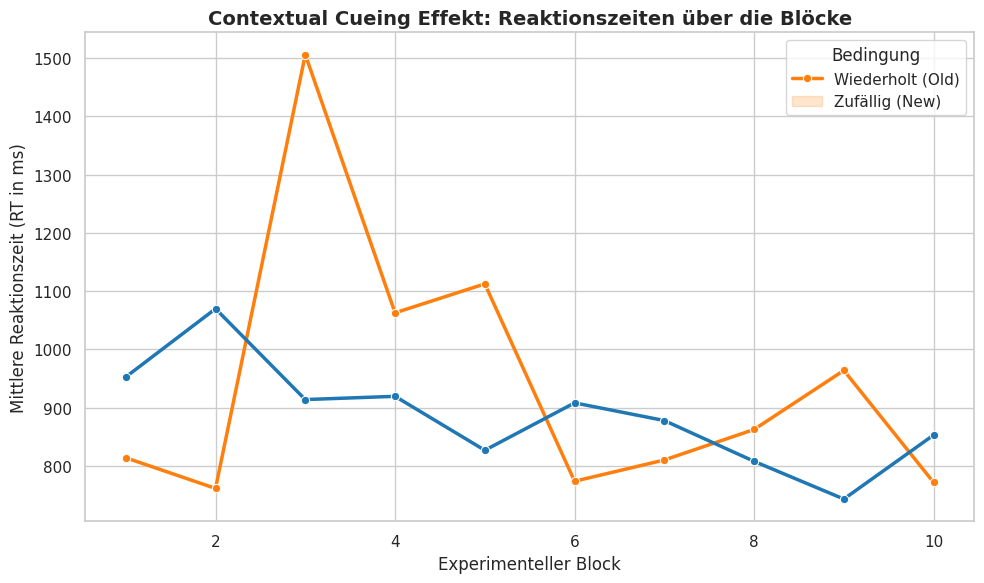


--- Führe Task 4 aus: Assumption Checks ---
--- 1. Shapiro-Wilk-Test auf Normalverteilung ---
Bedingung 'new': p-Wert = nan
Bedingung 'old': p-Wert = nan

--- 2. Levene-Test auf Varianzhomogenität ---
Levene-Test p-Wert = nan

--- Führe Task 5 aus: Inferenzstatistik ---
t-Statistik: nan | p-Wert: nan | Cohen's d: nan

--- Führe Task 6 aus: Multilevel Modeling ---
                  Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      rt         
No. Observations:        118          Method:                  REML       
No. Groups:              1            Scale:                   122166.7409
Min. group size:         118          Log-Likelihood:          -848.0365  
Max. group size:         118          Converged:               Yes        
Mean group size:         118.0                                            
--------------------------------------------------------------------------
                   Coef.        Std.Err.      z    P

/tmp/ipykernel_1126/3865390485.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = stats.shapiro(subset)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_morestats.py:3104: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/usr/local/lib/python3.13/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/usr/local/lib/python3.13/dist-packages/scipy/stats/_stats_py.py:1243: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_meth

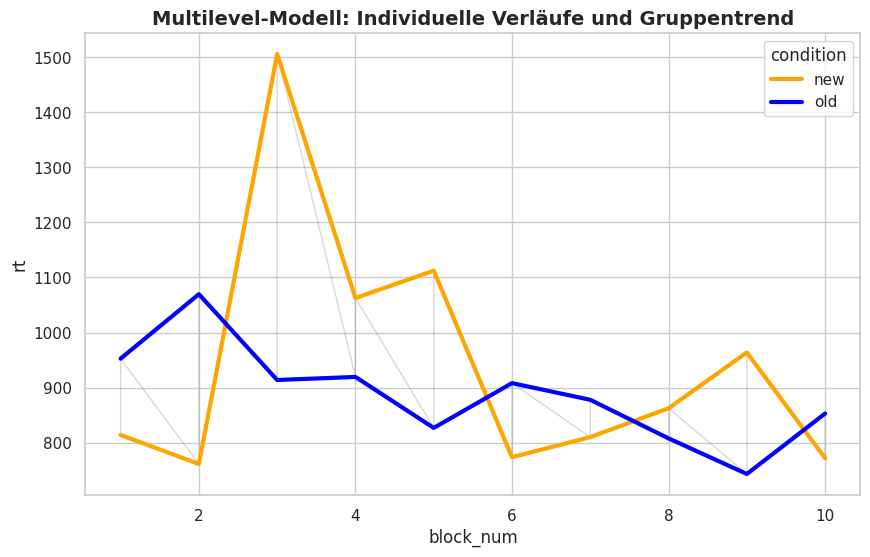

In [37]:
# ==========================================
# AUSFÜHRUNG DER ANALYSEN
# ==========================================

print(anzahl_zeilen := f"Anzahl Zeilen im DataFrame: {len(df)}")

if not df.empty:
    # 1. Task 2: Daten aggregieren
    print("\n--- Führe Task 2 aus: Aggregation ---")
    df_block_agg, df_subject_agg = aggregate_data(df)
    print("Aggregation erfolgreich abgeschlossen.")

    # 2. Task 3: Visualisierung (Lernkurve)
    print("\n--- Führe Task 3 aus: Visualisierung ---")
    plot_contextual_cueing(df_block_agg)

    # 3. Task 4: Voraussetzungen prüfen
    print("\n--- Führe Task 4 aus: Assumption Checks ---")
    check_assumptions(df_subject_agg)

    # 4. Task 5: Inferenzstatistik (t-Test & Effektstärke)
    print("\n--- Führe Task 5 aus: Inferenzstatistik ---")
    run_inferential_stats(df_subject_agg)

    # 5. Task 6: Multilevel Model & Spaghetti-Plot
    print("\n--- Führe Task 6 aus: Multilevel Modeling ---")
    run_multilevel_model(df)
else:
    print("Achtung: Der DataFrame 'df' ist leer. Bitte prüfe, ob deine CSV-Dateien auf OSF Daten enthalten und ob das Projekt öffentlich ist.")